In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import nltk
import gensim
from gensim import corpora
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
import seaborn as sns
import matplotlib.pyplot as plt
import re
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#Importing File
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks/data_news - data_news.csv'
df = pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,category,headline,links,short_description,keywords
0,WELLNESS,143 Miles in 35 Days: Lessons Learned,https://www.huffingtonpost.com/entry/running-l...,Resting is part of training. I've confirmed wh...,running-lessons
1,WELLNESS,Talking to Yourself: Crazy or Crazy Helpful?,https://www.huffingtonpost.com/entry/talking-t...,Think of talking to yourself as a tool to coac...,talking-to-yourself-crazy
2,WELLNESS,Crenezumab: Trial Will Gauge Whether Alzheimer...,https://www.huffingtonpost.com/entry/crenezuma...,The clock is ticking for the United States to ...,crenezumab-alzheimers-disease-drug
3,WELLNESS,"Oh, What a Difference She Made",https://www.huffingtonpost.com/entry/meaningfu...,"If you want to be busy, keep trying to be perf...",meaningful-life
4,WELLNESS,Green Superfoods,https://www.huffingtonpost.com/entry/green-sup...,"First, the bad news: Soda bread, corned beef a...",green-superfoods


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   category           50000 non-null  object
 1   headline           50000 non-null  object
 2   links              50000 non-null  object
 3   short_description  50000 non-null  object
 4   keywords           47332 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


In [ ]:
df.isnull().sum()


,0
category,0
headline,0
links,0
short_description,0
keywords,2668


In [ ]:
df['keywords']=df['keywords'].fillna(' ')
df.drop('links', axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
category,0
headline,0
short_description,0
keywords,0


In [ ]:
df['category'].unique()

array(['WELLNESS', 'POLITICS', 'ENTERTAINMENT', 'TRAVEL',
       'STYLE & BEAUTY', 'PARENTING', 'FOOD & DRINK', 'WORLD NEWS',
       'BUSINESS', 'SPORTS'], dtype=object)

In [ ]:
df['category'].value_counts()


,count
category,
WELLNESS,5000
POLITICS,5000
ENTERTAINMENT,5000
TRAVEL,5000
STYLE & BEAUTY,5000
PARENTING,5000
FOOD & DRINK,5000
WORLD NEWS,5000
BUSINESS,5000


/tmp/ipython-input-4073613148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, palette='pastel')


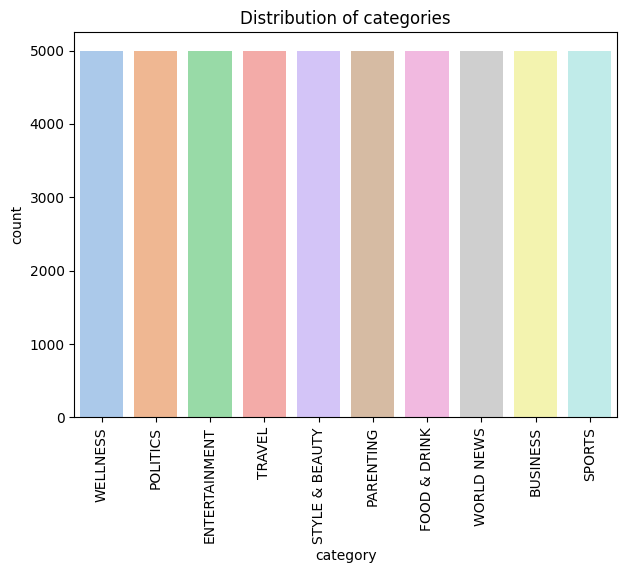

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='category', data=df, palette='pastel')
plt.title("Distribution of categories")
plt.xticks(rotation=90)
plt.show()


Insights:

The dataset is ideal for classification tasks because it is perfectly balanced.
can confidently use Accuracy as a primary metric, as it won't be skewed by one class dominating the predictions.

In [ ]:
short_description_len=df['short_description'].str.len().describe()
headline_len=df['headline'].str.len().describe()
print(f"Text length analysis for short description: {short_description_len}")
print(f"\nText length analysis for headline: {headline_len}")

Text length analysis for short description: count    50000.000000
mean       133.350120
std         77.789444
min          1.000000
25%         82.000000
50%        122.000000
75%        167.000000
max       1392.000000
Name: short_description, dtype: float64

Text length analysis for headline: count    50000.000000
mean        56.820580
std         19.429163
min          4.000000
25%         43.000000
50%         57.000000
75%         70.000000
max        295.000000
Name: headline, dtype: float64


Conclusion:

Short description: The data is generally centered, but there are notable outliers at both extremes of the scale. The presence of single-character values indicates a data quality issue that should be addressed through removal or imputation.

Headline: The text length is consistently stable and dependable, making outlier handling less of a concern for this column.

In [ ]:
df['description_length'] = df['short_description'].str.len()

# 2. Create a Boolean mask: length is less than or equal to 5
short_description_mask = df['description_length'] <= 5

# 3. Filter the DataFrame using the mask
short_articles = df[short_description_mask]
short_articles

,category,headline,short_description,keywords,description_length
5812,POLITICS,West Virginia Governor Brings Out Actual Bulls...,💩,jim-justice-budget-bill,1
8271,POLITICS,Here's What Would Have To Happen For Jeb Bush ...,💋,jeb-bush-warm-kiss,1
10616,ENTERTAINMENT,"This Is Where The Word 'Meme' Comes From, And ...",Huh!,origin-word-meme,4
11719,ENTERTAINMENT,Fleetwood Mac's Lindsey Buckingham And Christi...,🙌 🙌 🙌,christine-mcvie-lindsey-buckingham-duets-album,5
12580,ENTERTAINMENT,Jennifer Lawrence And Chris Pratt Are In A Lea...,OUCH!,jennifer-lawrence-chris-pratt-insults,5
12719,ENTERTAINMENT,Ariana Grande Gives Fans Singing 'One Last Tim...,OMG!,ariana-grande-surprises-fans,4
13458,ENTERTAINMENT,Teen Wolf' Actors Say Their Goodbyes To The Se...,😭 😭 😭,teen-wolf-wraps-filming-actor-goodbyes,5
15111,TRAVEL,A Friendly Reminder That There Were 0 Fatal Je...,👍👏,fatal-jet-accident-rate,2
15302,TRAVEL,You Can Order Room Service With Emojis. Peak L...,👏🏨 💥,emoji-room-service-aloft-hotels,4
20606,STYLE & BEAUTY,Kim Kardashian Accessorizes With A Kitten (PHOTO),Meow!,kim-kardashian-2012-photo,5


Insights on Shortest Articles (Length ≤ 5):

It is evident that the short descriptions consist mainly of emojis, brief exclamations, or single words intended to respond to the headline, rather than providing meaningful content.

These short descriptions introduce noise for the TF-IDF Vectorizer, as they lack enough unique words or context to effectively classify the article's topic. Including them would only reduce the quality of the feature set.

In [ ]:
df_cleaned = df[df['description_length'] > 5].copy()

# 2. Verify the size of the cleaned dataset
rows_dropped = len(df) - len(df_cleaned)
print(f"Original Row Count: {len(df)}")
print(f"Cleaned Row Count: {len(df_cleaned)}")
print(f"Total Rows Dropped (Noise): {rows_dropped}")

Original Row Count: 50000
Cleaned Row Count: 49965
Total Rows Dropped (Noise): 35


In [ ]:
df_cleaned['combined_text'] = (
    df_cleaned['headline'].astype(str) + ' ' +
    df_cleaned['short_description'].astype(str) + ' ' +
    df_cleaned['keywords'].astype(str)
)

In [ ]:
df_cleaned.head()

,category,headline,short_description,keywords,description_length,combined_text
0,WELLNESS,143 Miles in 35 Days: Lessons Learned,Resting is part of training. I've confirmed wh...,running-lessons,280,143 Miles in 35 Days: Lessons Learned Resting ...
1,WELLNESS,Talking to Yourself: Crazy or Crazy Helpful?,Think of talking to yourself as a tool to coac...,talking-to-yourself-crazy,216,Talking to Yourself: Crazy or Crazy Helpful? T...
2,WELLNESS,Crenezumab: Trial Will Gauge Whether Alzheimer...,The clock is ticking for the United States to ...,crenezumab-alzheimers-disease-drug,120,Crenezumab: Trial Will Gauge Whether Alzheimer...
3,WELLNESS,"Oh, What a Difference She Made","If you want to be busy, keep trying to be perf...",meaningful-life,106,"Oh, What a Difference She Made If you want to ..."
4,WELLNESS,Green Superfoods,"First, the bad news: Soda bread, corned beef a...",green-superfoods,125,"Green Superfoods First, the bad news: Soda bre..."


In [ ]:
# Preprocessing Dataset

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # 2. Remove non-letter characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # 3. Convert to lowercase
    text = text.lower()

   # 4. Tokenize words
    tokens = word_tokenize(text)

    # 5. Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # 6. Join tokens back to string
    return ' '.join(tokens)

In [ ]:
df_cleaned['clean_combinedtext'] = df_cleaned['combined_text'].apply(preprocess_text)
df_cleaned[['combined_text', 'clean_combinedtext']].head()

,combined_text,clean_combinedtext
0,143 Miles in 35 Days: Lessons Learned Resting ...,143 mile 35 day lesson learned resting part tr...
1,Talking to Yourself: Crazy or Crazy Helpful? T...,talking crazy crazy helpful think talking tool...
2,Crenezumab: Trial Will Gauge Whether Alzheimer...,crenezumab trial gauge whether alzheimer drug ...
3,"Oh, What a Difference She Made If you want to ...",oh difference made want busy keep trying perfe...
4,"Green Superfoods First, the bad news: Soda bre...",green superfoods first bad news soda bread cor...


In [ ]:
# Splitting the Data



le = LabelEncoder()
x=df_cleaned['clean_combinedtext']
y=le.fit_transform(df_cleaned['category'])

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# Feature Engineering

# Bag of Words

bow = CountVectorizer(max_features=5000)
x_train_bow = bow.fit_transform(x_train)
x_test_bow = bow.transform(x_test)

In [ ]:
# Step 1: Tokenize text
tokenized_text = [text.split() for text in df_cleaned['clean_combinedtext']]

# Step 2: Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_text,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

# Step 3: Create average Word2Vec vector for each review
def get_vector(tokens):
    vec = np.zeros(100)
    count = 0
    for word in tokens:
        if word in w2v_model.wv:
            vec += w2v_model.wv[word]
            count += 1
    return vec / count if count > 0 else vec

df_cleaned['text_vector'] = [get_vector(tokens) for tokens in tokenized_text]
df_cleaned['text_vector']

,text_vector
0,"[-0.40916986252580373, 0.16510971408736494, -0..."
1,"[-0.43499477599796493, 0.22779605782737858, -0..."
2,"[-0.319021769411241, 0.2368086509522982, -0.27..."
3,"[-0.5755167325337728, 0.19383386589276294, -0...."
4,"[-0.38172235825148065, 0.0010258351991835394, ..."
...,...
49995,"[-0.33251345546349237, 0.29610733712173026, -0..."
49996,"[-0.41797493790325363, 0.21756286105435146, -0..."
49997,"[-0.33662429253260295, -0.022592360448713104, ..."
49998,"[-0.32952112425118685, 0.18514061272435356, -0..."


In [ ]:
# Tdidf Vectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
x_train_tfidf= vectorizer.fit_transform(x_train)
x_test_tfidf=vectorizer.transform(x_test)


In [ ]:
# Textual Features (Staistical)

# Word count
df_cleaned['word_count'] = df_cleaned['clean_combinedtext'].apply(lambda x: len(x.split()))

# Character count
df_cleaned['char_count'] = df_cleaned['clean_combinedtext'].apply(lambda x: len(x))

# Average word length
df_cleaned['avg_word_length'] = df_cleaned['clean_combinedtext'].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

# Unique word ratio
df_cleaned['unique_word_ratio'] = df_cleaned.apply(lambda row: len(set(row['clean_combinedtext'].split())) / row['word_count']
    if row['word_count'] > 0 else 0, axis=1)

In [ ]:
# Textual features dataframe
text_features = df_cleaned[['word_count', 'char_count', 'avg_word_length', 'unique_word_ratio']]

# Split them according to the same indices as TF-IDF
x_train_text = text_features.loc[x_train.index]
x_test_text = text_features.loc[x_test.index]

print(f"Statistical Features Shape (Train): {x_train_text.shape}")


Statistical Features Shape (Train): (39972, 4)


In [ ]:
from scipy.sparse import hstack

# Combine TF-IDF with textual features
x_train_combined = hstack([x_train_tfidf, x_train_text])
x_test_combined = hstack([x_test_tfidf, x_test_text])

print("x-train:",x_train_combined.shape)
print("x-test:",x_test_combined.shape)

x-train: (39972, 5004)
x-test: (9993, 5004)


TF-IDF vs Word2Vec:

Simplicity & Speed: TF-IDF is faster to compute, making it better suited for large datasets like IMDb. It quickly transforms text into numerical features without requiring complex models.

Works Well with Linear Models: TF-IDF performs well with linear models like Logistic Regression, which thrives on sparse, high-dimensional features, making it an efficient choice for classification tasks.

Captures Word Importance: TF-IDF focuses on important sentiment-laden words, such as "good" or "terrible," which improves the model's ability to classify sentiment effectively.

Adds Context: In addition to word frequency, TF-IDF can incorporate additional features like word count and punctuation, which can provide context (e.g., emotional tone) that Word2Vec might miss.

Cons of Word2Vec:

Requires Aggregation: Word2Vec represents words as vectors but requires aggregation (like averaging word vectors), which loses word order and detailed context, potentially reducing accuracy.

Underperforms with Simple Models: In simpler models, Word2Vec often underperforms compared to TF-IDF. For example, in this project, TF-IDF achieved 89% accuracy, while Word2Vec only reached 73%, showing TF-IDF's superior performance in basic classification tasks.


 Logistic Regression
Accuracy: 0.8121
ROC–AUC: 0.9735
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       999
           1       0.78      0.82      0.80       999
           2       0.86      0.88      0.87      1000
           3       0.80      0.77      0.79      1000
           4       0.77      0.76      0.77      1000
           5       0.87      0.88      0.88       997
           6       0.88      0.84      0.86       999
           7       0.81      0.80      0.80      1000
           8       0.76      0.81      0.78      1000
           9       0.80      0.81      0.80       999

    accuracy                           0.81      9993
   macro avg       0.81      0.81      0.81      9993
weighted avg       0.81      0.81      0.81      9993



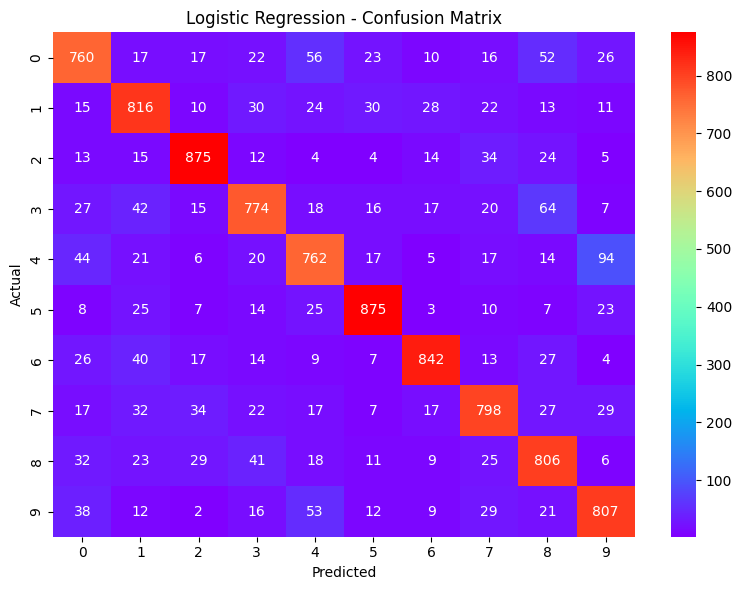


 Naive Bayes
Accuracy: 0.7969
ROC–AUC: 0.9733
              precision    recall  f1-score   support

           0       0.76      0.73      0.75       999
           1       0.80      0.77      0.79       999
           2       0.84      0.86      0.85      1000
           3       0.74      0.77      0.75      1000
           4       0.80      0.73      0.77      1000
           5       0.88      0.85      0.86       997
           6       0.89      0.81      0.85       999
           7       0.76      0.82      0.79      1000
           8       0.73      0.79      0.76      1000
           9       0.78      0.83      0.81       999

    accuracy                           0.80      9993
   macro avg       0.80      0.80      0.80      9993
weighted avg       0.80      0.80      0.80      9993



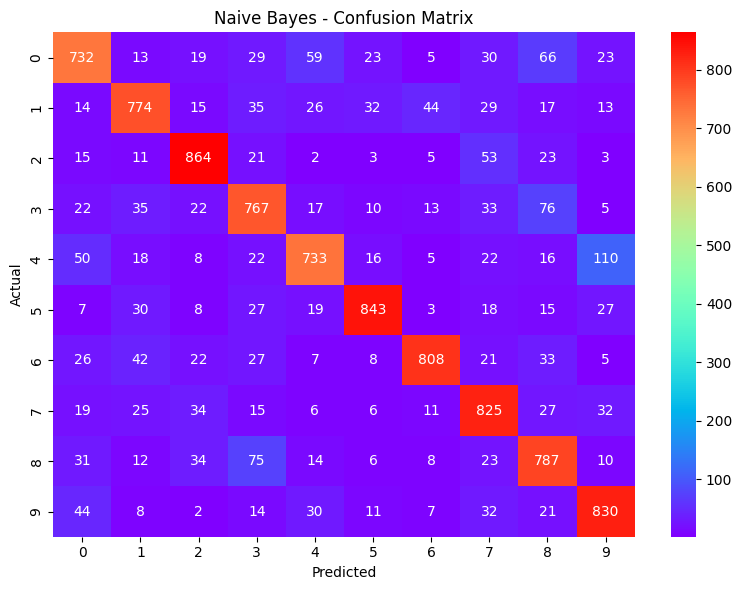


 SVM
Accuracy: 0.8172
ROC–AUC: 0.971
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       999
           1       0.81      0.80      0.80       999
           2       0.86      0.88      0.87      1000
           3       0.79      0.77      0.78      1000
           4       0.78      0.75      0.76      1000
           5       0.87      0.92      0.90       997
           6       0.88      0.87      0.88       999
           7       0.81      0.80      0.80      1000
           8       0.76      0.77      0.76      1000
           9       0.81      0.82      0.81       999

    accuracy                           0.82      9993
   macro avg       0.82      0.82      0.82      9993
weighted avg       0.82      0.82      0.82      9993



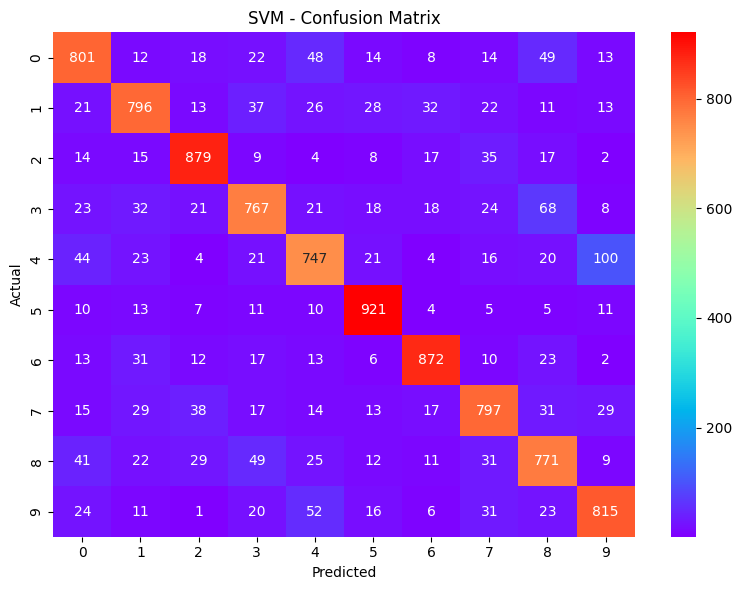


 Random Forest
Accuracy: 0.737
ROC–AUC: 0.9587
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       999
           1       0.62      0.69      0.65       999
           2       0.73      0.80      0.77      1000
           3       0.74      0.75      0.74      1000
           4       0.73      0.63      0.68      1000
           5       0.87      0.91      0.89       997
           6       0.80      0.79      0.80       999
           7       0.74      0.63      0.68      1000
           8       0.63      0.71      0.67      1000
           9       0.71      0.65      0.68       999

    accuracy                           0.74      9993
   macro avg       0.74      0.74      0.74      9993
weighted avg       0.74      0.74      0.74      9993



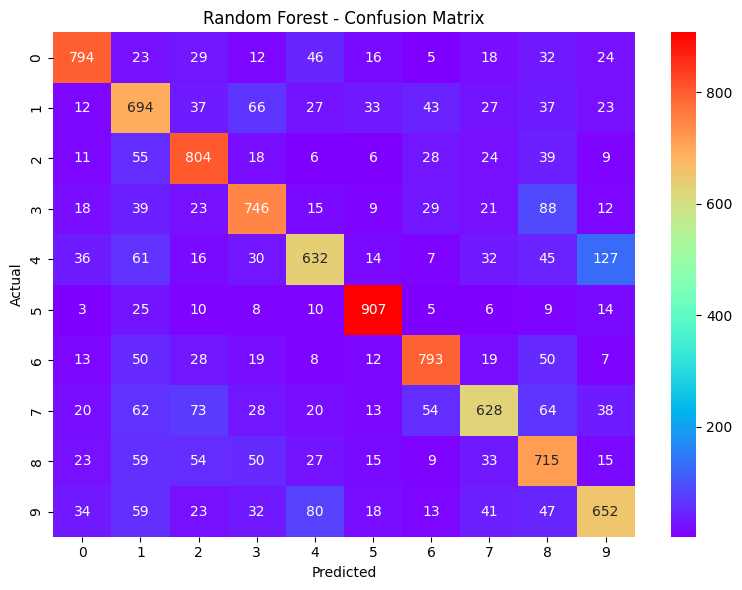

In [ ]:
# Model Delvelopment

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver='lbfgs', n_jobs=-1),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
classes = np.unique(y_train)  # get unique class labels

for name, model in models.items():

    model.fit(x_train_combined, y_train)
    y_pred = model.predict(x_test_combined)

    # --- Handle ROC–AUC safely ---
    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(x_test_combined)
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(x_test_combined)

    if y_proba is not None:
        try:
            y_test_bin = label_binarize(y_test, classes=classes)
            roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
        except Exception as e:
            roc_auc = np.nan
            print(f"ROC–AUC skipped for {name}: {e}")
    else:
        roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)

    print(f"\n {name}")
    print("Accuracy:", round(acc, 4))
    print("ROC–AUC:", round(roc_auc, 4) if not np.isnan(roc_auc) else "N/A")
    print(classification_report(y_test, y_pred))

    results.append((name, acc, roc_auc))

    # --- Confusion Matrix ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap='rainbow',xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f'{name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Summary Table ---
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC–AUC"])
print("\n Model Performance Summary:")
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df)


 Model Performance Summary:
                 Model  Accuracy   ROC–AUC
2                  SVM  0.817172  0.970960
0  Logistic Regression  0.812068  0.973475
1          Naive Bayes  0.796858  0.973336
3        Random Forest  0.737016  0.958722


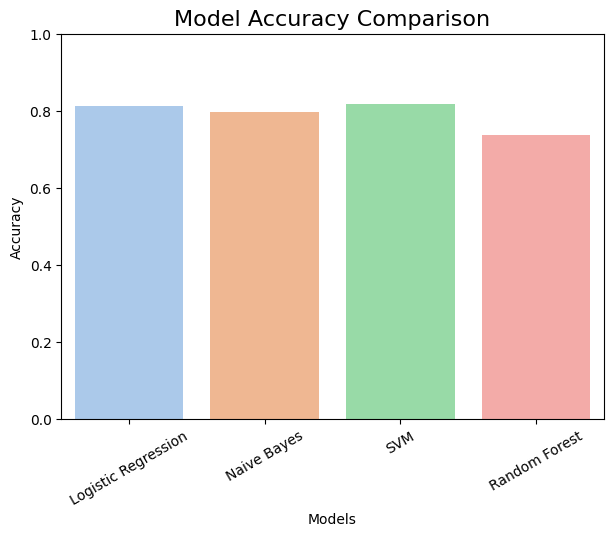

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC–AUC"])


plt.figure(figsize=(7, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy",hue="Model", palette="pastel", legend=False)
plt.title("Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

Key Insights:

SVM: Achieved the best accuracy and strong AUC, indicating excellent overall performance and a balanced ability to predict both classes effectively.

Logistic Regression: Slightly lower accuracy but the highest AUC, showing it distinguishes well between the classes, indicating strong generalization.

Naive Bayes: Performs well for its simplicity, making it effective for text data with word frequency features like TF-IDF.

Random Forest: Has the lowest accuracy and AUC, possibly because it struggles to capture the nuanced relationships in text data compared to linear models.

Conclusion:

Both SVM and Logistic Regression performed strongly in classifying news articles, with SVM standing out as the better model due to its slightly higher accuracy and robustness across categories.

The models' strong ability to differentiate between topics makes them ideal for real-world applications like news recommendation systems, topic tagging, and automated editorial workflows, where understanding and classifying diverse topics accurately is crucial.